# PPO (Proximal Policy Optimization) 알고리즘 기본 실습

## 학습 목표
- PPO 알고리즘의 핵심 개념 이해
- Clipping 메커니즘의 작동 원리 체험
- CartPole 환경에서 안정적인 학습 경험

---

## 1단계: 필요한 라이브러리 설치 및 불러오기

In [3]:
import numpy as np

type(np.array(3.14))

numpy.ndarray

적용 폰트: NanumGothic


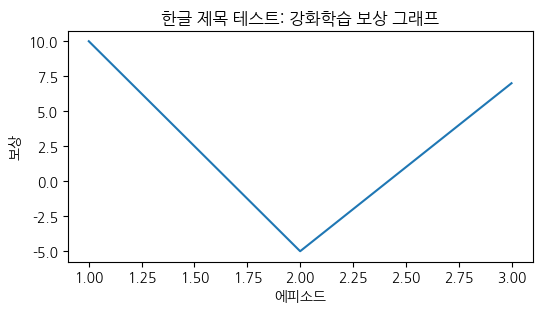

In [1]:
# 1) 한글 폰트 설치 (런타임 1회)
# !apt-get -qq update
# !apt-get -qq install -y fonts-nanum

# 2) Matplotlib에 한글 폰트 적용
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 경로 찾기
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

# 폰트 이름 가져오기(환경에 따라 정확한 이름이 다를 수 있어서 안전하게)
font_name = fm.FontProperties(fname=font_path).get_name()
print("적용 폰트:", font_name)

# 전역 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False  # ✅ 마이너스(-) 깨짐 방지

# 3) 테스트
plt.figure(figsize=(6,3))
plt.plot([1,2,3], [10,-5,7])
plt.title("한글 제목 테스트: 강화학습 보상 그래프")
plt.xlabel("에피소드")
plt.ylabel("보상")
plt.show()

In [ ]:
# 필요한 라이브러리 설치
# !pip install gymnasium torch matplotlib numpy -q

**설명**: PPO 실습에 필요한 패키지들을 설치합니다.
- REINFORCE와 동일한 환경 사용
- 추가적인 패키지는 필요 없음

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("라이브러리 불러오기 완료")
print(f"PyTorch 버전: {torch.__version__}")

라이브러리 불러오기 완료
PyTorch 버전: 2.10.0+cu130


---

## 2단계: PPO란 무엇인가?

### REINFORCE의 문제점
- 학습이 불안정함 (갑자기 성능이 나빠질 수 있음)
- 한 번 수집한 데이터를 버림 (비효율적)

### PPO의 해결책
- **Clipping**: 정책이 너무 많이 변하지 않도록 제한
- **Multiple Epochs**: 같은 데이터로 여러 번 학습 (효율적)

**비유**:
- REINFORCE: 한 번에 큰 걸음 → 넘어질 수 있음
- PPO: 조금씩 안전하게 걸음 → 안정적

---

## 3단계: Actor와 Critic 네트워크 만들기

PPO는 두 개의 신경망을 사용합니다.
- **Actor**: 행동 선택 (정책)
- **Critic**: 상태 평가 (가치)

In [3]:
def create_actor_network(state_dim, action_dim, hidden_dim=128):
    """
    Actor 네트워크: 어떤 행동을 할지 결정

    입력: 상태 (4차원)
    출력: 행동 확률 (2차원)
    """
    model = nn.Sequential(
        nn.Linear(state_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, action_dim)
    )
    return model

def create_critic_network(state_dim, hidden_dim=128):
    """
    Critic 네트워크: 상태가 얼마나 좋은지 평가

    입력: 상태 (4차원)
    출력: 가치 (1차원)
    """
    model = nn.Sequential(
        nn.Linear(state_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1)
    )
    return model

# 네트워크 생성
state_dim = 4
action_dim = 2

actor = create_actor_network(state_dim, action_dim)
critic = create_critic_network(state_dim)

print("Actor 네트워크:")
print(actor)
print(f"\nCritic 네트워크:")
print(critic)

Actor 네트워크:
Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=2, bias=True)
)

Critic 네트워크:
Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
)


**설명**: Actor-Critic 구조
- **Actor**: "이 상태에서 왼쪽/오른쪽 중 뭐가 좋을까?" 결정
- **Critic**: "이 상태는 얼마나 좋은 상태인가?" 평가

**협업**:
- Actor: 행동 선택
- Critic: Actor가 잘하고 있는지 평가

---

## 4단계: 행동 선택 및 가치 계산

In [9]:
torch.distributions.Categorical(torch.tensor([[0.7,0.2,0.1,0.1],[0.7,0.1,0.1,0.1],[0.7,0.1,0.1,0.1]]))
# a = torch.randn(3,4)
# torch.distributions.Categorical(torch.randn(3,4))
# a

Categorical(probs: torch.Size([3, 4]))

In [10]:
def select_action(actor, state):
    """
    Actor로 행동 선택
    """
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    logits = actor(state_tensor)
    action_probs = torch.softmax(logits, dim=-1)
    dist = torch.distributions.Categorical(action_probs)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    # 수치 안정성
    return action.item(), log_prob

def evaluate_state(critic, state):
    """
    Critic으로 상태 가치 평가
    """
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    value = critic(state_tensor) # (1,1)
    return value.squeeze() # (1)

# 테스트
test_state = np.array([0.01, 0.2, 0.03, -0.5])
action, log_prob = select_action(actor, test_state)
value = evaluate_state(critic, test_state)

print(f"테스트 상태: {test_state}")
print(f"Actor 선택: {action} ({'왼쪽' if action == 0 else '오른쪽'})")
print(f"Critic 평가: 이 상태의 가치 = {value.item():.3f}")

테스트 상태: [ 0.01  0.2   0.03 -0.5 ]
Actor 선택: 1 (오른쪽)
Critic 평가: 이 상태의 가치 = 0.024


**설명**:
- **select_action**: Actor가 확률적으로 행동 선택
- **evaluate_state**: Critic이 현재 상태가 얼마나 좋은지 평가

**예시**: 막대가 많이 기울어진 상태 → Critic이 낮은 점수 부여

---

## 5단계: 데이터 수집하기

In [13]:
def collect_trajectories(env, actor, critic, num_steps=1000):
    """
    여러 에피소드 실행하여 경험 수집

    num_steps: 수집할 총 스텝 수
    """
    states = []     # 궤적 추적(방문한 모든 상태) 저장
    actions = []    # 선택한 모든 행동 저장
    rewards = []    # 받은 모든 보상 저장
    log_probs = []  # 각 행동의 log 확률 
    values = []     # critic의 평가 저장
    dones = []      # 에피소드 종료 여부 저장 (True, False)

    state, _ = env.reset()
    episode_rewards = []
    current_episode_reward = 0

    for step in range(num_steps):
        # 행동 선택 및 가치 평가
        action, log_prob = select_action(actor, state)
        value = evaluate_state(critic, state)

        # 환경과 상호작용
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 저장
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob.item())
        values.append(value.item())
        dones.append(done)

        current_episode_reward += reward
        state = next_state

        if done:
            episode_rewards.append(current_episode_reward)
            state, _ = env.reset()
            current_episode_reward = 0

    return {
        'states': np.array(states),
        'actions': np.array(actions),
        'rewards': rewards,
        'log_probs': np.array(log_probs),
        'values': np.array(values),
        'dones': dones,
        'episode_rewards': episode_rewards
    }

# 테스트
env = gym.make('CartPole-v1')
data = collect_trajectories(env, actor, critic, num_steps=500)
print(f"수집된 스텝: {len(data['rewards'])}")
print(f"완료된 에피소드: {len(data['episode_rewards'])}")
print(f"평균 에피소드 보상: {np.mean(data['episode_rewards']):.2f}")
env.close()

수집된 스텝: 500
완료된 에피소드: 23
평균 에피소드 보상: 20.61


**설명**: 경험 수집
- 현재 정책으로 1000 스텝 플레이
- 모든 상태, 행동, 보상 기록
- 여러 에피소드가 포함됨

**PPO의 장점**: 이 데이터를 여러 번 재사용 가능 (효율적)

---

## 6단계: Advantage 계산 (GAE)

Advantage = "평균보다 얼마나 좋은가?"

In [14]:
def compute_gae(rewards, values, dones, gamma=0.99, lambda_=0.95):
    """
    A(s, a) = Q(s, a) - V(s)
    여기서 V(s) 평균 점수
    Generalized Advantage Estimation (GAE)

    gamma: 할인 계수
    lambda_: GAE 파라미터 (0~1)
    """
    advantages = []
    gae = 0

    # 다음 상태 가치 (마지막은 0)
    next_values = values[1:].tolist() + [0]

    # 역순으로 계산
    for i in reversed(range(len(rewards))):
        if dones[i]:
            # 에피소드 종료 시
            delta = rewards[i] - values[i]
            gae = delta
        else:
            # TD error
            delta = rewards[i] - values[i] + gamma * next_values[i]
            # GAE 계산 (누적)
            gae = delta + gamma * lambda_ * gae

        advantages.insert(0, gae)

    advantages = np.array(advantages)
    # 평균보다 좋은 결과 >> 미래의 좋은 결과가 현재 행동의 advantage 높여줌

    # Returns 계산 (Advantage + Value)
    returns = advantages + values

    # 정규화
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return advantages, returns

# 테스트
advantages, returns = compute_gae(
    data['rewards'],
    data['values'],
    data['dones']
)

print(f"Advantage 평균: {advantages.mean():.3f}")
print(f"Advantage 표준편차: {advantages.std():.3f}")
print(f"Returns 평균: {returns.mean():.3f}")

Advantage 평균: 0.000
Advantage 표준편차: 1.000
Returns 평균: 8.087


**설명**: GAE (Generalized Advantage Estimation)
- **Advantage > 0**: 이 행동이 평균보다 좋음 → 확률 증가
- **Advantage < 0**: 이 행동이 평균보다 나쁨 → 확률 감소

**GAE의 장점**:
- REINFORCE보다 분산이 작음 (안정적)
- Bias-Variance 조절 가능

---

## 7단계: PPO Clipping 이해하기

PPO의 핵심 메커니즘!

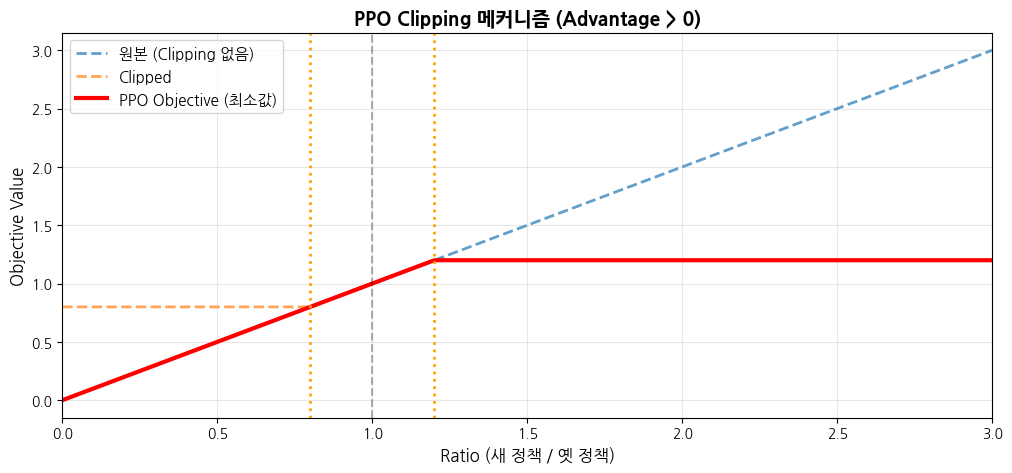

=== PPO Clipping 설명 ===
Epsilon: 0.2
허용 범위: [0.8, 1.2]

Ratio가 1.2를 넘으면 (너무 큰 변화):
  -> 1.2로 제한 (Clipping)
  -> 정책이 너무 많이 변하는 것 방지

결과: 안정적인 학습!


In [15]:
# Clipping 시각화
epsilon = 0.2  # Clipping 범위

# Ratio 범위
ratio = np.linspace(0, 3, 300)

# Advantage > 0인 경우
advantage_pos = 1.0
unclipped_pos = ratio * advantage_pos
clipped_pos = np.clip(ratio, 1-epsilon, 1+epsilon) * advantage_pos
objective_pos = np.minimum(unclipped_pos, clipped_pos)

# 그래프 그리기
plt.figure(figsize=(12, 5))

plt.plot(ratio, unclipped_pos, '--', label='원본 (Clipping 없음)', linewidth=2, alpha=0.7)
plt.plot(ratio, clipped_pos, '--', label='Clipped', linewidth=2, alpha=0.7)
plt.plot(ratio, objective_pos, '-', label='PPO Objective (최소값)', linewidth=3, color='red')
plt.axvline(x=1-epsilon, color='orange', linestyle=':', linewidth=2)
plt.axvline(x=1+epsilon, color='orange', linestyle=':', linewidth=2)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.3)

plt.xlabel('Ratio (새 정책 / 옛 정책)', fontsize=12)
plt.ylabel('Objective Value', fontsize=12)
plt.title('PPO Clipping 메커니즘 (Advantage > 0)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 3])
plt.show()

print("=== PPO Clipping 설명 ===")
print(f"Epsilon: {epsilon}")
print(f"허용 범위: [{1-epsilon}, {1+epsilon}]")
print("\nRatio가 1.2를 넘으면 (너무 큰 변화):")
print("  -> 1.2로 제한 (Clipping)")
print("  -> 정책이 너무 많이 변하는 것 방지")
print("\n결과: 안정적인 학습!")

**설명**: PPO Clipping의 핵심

**Ratio (r)**:
- r = 새 정책의 확률 / 옛 정책의 확률
- r = 1: 정책이 변하지 않음
- r > 1: 이 행동의 확률이 증가
- r < 1: 이 행동의 확률이 감소

**Clipping**:
- r이 [0.8, 1.2] 범위를 벗어나면 잘라냄
- 정책이 급격히 변하는 것 방지
- 학습 안정성 대폭 향상

---

## 8단계: PPO 업데이트

In [ ]:
def ppo_update(actor, critic, actor_optimizer, critic_optimizer,
               states, actions, old_log_probs, advantages, returns,
               epsilon=0.2, epochs=10, batch_size=64):
    """
    PPO 업데이트

    핵심: 같은 데이터로 여러 번(epochs) 학습
    """
    # Tensor로 변환
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    old_log_probs = torch.FloatTensor(old_log_probs)
    advantages = torch.FloatTensor(advantages)
    returns = torch.FloatTensor(returns)

    dataset_size = len(states)

    for epoch in range(epochs):
        # 데이터 섞기
        indices = np.random.permutation(dataset_size) # 랜덤 순서 인덱스 반환

        # 미니배치로 학습
        for start in range(0, dataset_size, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            # [0:64]
            # [64:128]

            batch_states = states[batch_indices]
            batch_actions = actions[batch_indices]
            batch_old_log_probs = old_log_probs[batch_indices]
            batch_advantages = advantages[batch_indices]
            batch_returns = returns[batch_indices]

            # 새 정책으로 log_prob 계산
            logits = actor(batch_states)
            probs = torch.softmax(logits, dim=-1)
            dist = torch.distributions.Categorical(probs)
            new_log_probs = dist.log_prob(batch_actions)

            # Ratio 계산
            ratio = torch.exp(new_log_probs - batch_old_log_probs) # => new/old

            # PPO Clipped Objective
            surr1 = ratio * batch_advantages
            surr2 = torch.clamp(ratio, 1-epsilon, 1+epsilon) * batch_advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            # 우리의 목표(objective)는 이득을 최대화 >> loss니깐 '-' 곱해서 최소화 문제로 변환

            # Actor 업데이트
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            # Critic 업데이트
            values = critic(batch_states).squeeze()
            critic_loss = nn.MSELoss()(values, batch_returns)

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

print("PPO 업데이트 함수 준비 완료")

PPO 업데이트 함수 준비 완료


**설명**: PPO 업데이트 과정

1. **여러 epoch 반복** (10번):
   - 같은 데이터로 10번 학습
   - REINFORCE는 1번만 사용 후 버림

2. **미니배치 학습**:
   - 전체 데이터를 작은 배치로 나눔
   - 각 배치마다 업데이트

3. **Clipping 적용**:
   - Ratio가 범위 벗어나면 제한
   - 안정적 학습

4. **Actor & Critic 동시 업데이트**:
   - Actor: 정책 개선
   - Critic: 가치 추정 개선

---

## 9단계: 전체 PPO 학습 실행

In [17]:
# 하이퍼파라미터
actor_lr = 0.0003
critic_lr = 0.001
gamma = 0.99
lambda_ = 0.95
epsilon = 0.2
epochs = 10
batch_size = 64
num_updates = 50  # 업데이트 횟수
steps_per_update = 2000  # 업데이트당 수집 스텝

# 환경 및 네트워크 재생성
env = gym.make('CartPole-v1')
actor = create_actor_network(state_dim, action_dim)
critic = create_critic_network(state_dim)
actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

# 학습 기록
all_episode_rewards = []

print("=== PPO 학습 시작 ===")
print(f"총 업데이트: {num_updates}")
print(f"업데이트당 스텝: {steps_per_update}")
print(f"Epochs: {epochs}")
print(f"Epsilon: {epsilon}")
print()

for update in range(num_updates):
    # 1. 데이터 수집
    data = collect_trajectories(env, actor, critic, steps_per_update)

    # 2. Advantage 계산
    advantages, returns = compute_gae(
        data['rewards'],
        data['values'],
        data['dones'],
        gamma,
        lambda_
    )

    # 3. PPO 업데이트
    ppo_update(
        actor, critic,
        actor_optimizer, critic_optimizer,
        data['states'], data['actions'], data['log_probs'],
        advantages, returns,
        epsilon, epochs, batch_size
    )

    # 4. 기록
    all_episode_rewards.extend(data['episode_rewards'])

    # 5. 진행상황 출력
    if (update + 1) % 5 == 0:
        recent = all_episode_rewards[-20:] if len(all_episode_rewards) >= 20 else all_episode_rewards
        avg_reward = np.mean(recent) if recent else 0
        print(f"업데이트 {update+1}/{num_updates} | "
              f"에피소드: {len(all_episode_rewards)} | "
              f"평균 보상 (최근 20): {avg_reward:.2f}")

print("\n학습 완료!")
env.close()

=== PPO 학습 시작 ===
총 업데이트: 50
업데이트당 스텝: 2000
Epochs: 10
Epsilon: 0.2

업데이트 5/50 | 에피소드: 232 | 평균 보상 (최근 20): 139.15
업데이트 10/50 | 에피소드: 260 | 평균 보상 (최근 20): 361.60
업데이트 15/50 | 에피소드: 280 | 평균 보상 (최근 20): 472.50
업데이트 20/50 | 에피소드: 300 | 평균 보상 (최근 20): 500.00
업데이트 25/50 | 에피소드: 326 | 평균 보상 (최근 20): 366.25
업데이트 30/50 | 에피소드: 346 | 평균 보상 (최근 20): 492.25
업데이트 35/50 | 에피소드: 366 | 평균 보상 (최근 20): 500.00
업데이트 40/50 | 에피소드: 386 | 평균 보상 (최근 20): 500.00
업데이트 45/50 | 에피소드: 406 | 평균 보상 (최근 20): 500.00
업데이트 50/50 | 에피소드: 426 | 평균 보상 (최근 20): 500.00

학습 완료!


**설명**: PPO 학습 과정

1. **데이터 수집**: 2000 스텝 플레이
2. **Advantage 계산**: 어떤 행동이 좋았는지 분석
3. **업데이트**: 같은 데이터로 10번 학습 (효율적!)
4. **반복**: 50번 업데이트 = 총 100,000 스텝

**REINFORCE와 비교**:
- REINFORCE: 데이터 1번 사용
- PPO: 데이터 10번 재사용 → 10배 효율적!

---

## 10단계: 학습 결과 시각화

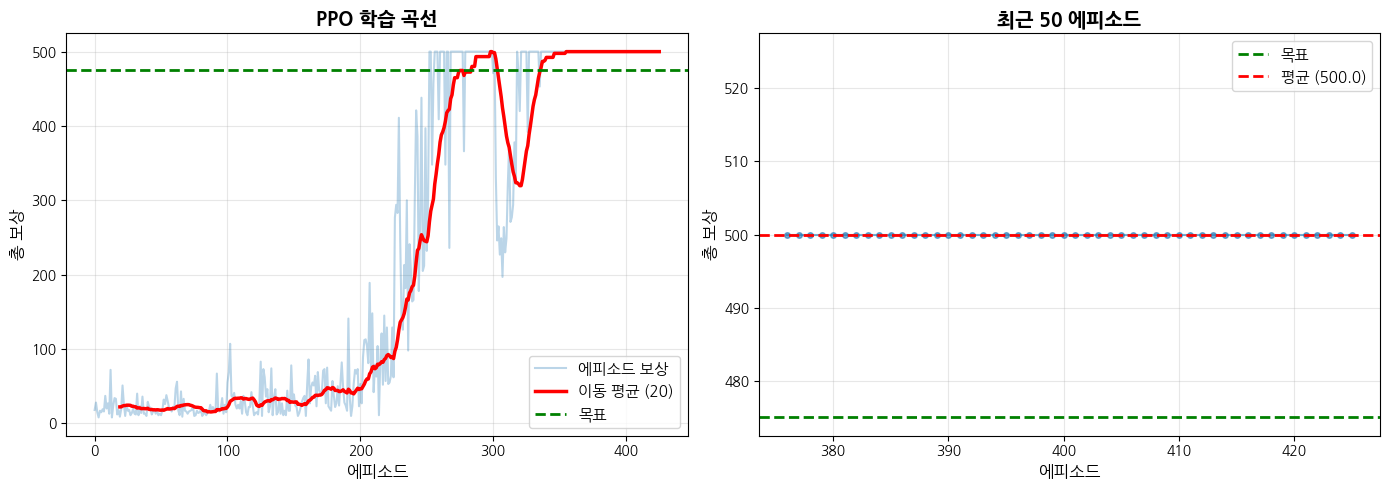


=== PPO 학습 결과 ===
총 에피소드: 426
평균 보상 (전체): 227.96
평균 보상 (최근 50): 500.00
최대 보상: 500
성공 에피소드 (>475): 147


In [18]:
# 학습 곡선
plt.figure(figsize=(14, 5))

# 전체 학습 곡선
plt.subplot(1, 2, 1)
plt.plot(all_episode_rewards, alpha=0.3, label='에피소드 보상')

window = 20
if len(all_episode_rewards) >= window:
    ma = np.convolve(all_episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(all_episode_rewards)), ma,
             label=f'이동 평균 ({window})', linewidth=2.5, color='red')

plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='목표')
plt.xlabel('에피소드', fontsize=12)
plt.ylabel('총 보상', fontsize=12)
plt.title('PPO 학습 곡선', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# 후반부 확대
plt.subplot(1, 2, 2)
if len(all_episode_rewards) >= 50:
    last_50 = all_episode_rewards[-50:]
    plt.plot(range(len(all_episode_rewards)-50, len(all_episode_rewards)), last_50,
             marker='o', markersize=4, alpha=0.6)
    plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='목표')
    plt.axhline(y=np.mean(last_50), color='red', linestyle='--',
               linewidth=2, label=f'평균 ({np.mean(last_50):.1f})')
    plt.xlabel('에피소드', fontsize=12)
    plt.ylabel('총 보상', fontsize=12)
    plt.title('최근 50 에피소드', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계
print("\n=== PPO 학습 결과 ===")
print(f"총 에피소드: {len(all_episode_rewards)}")
print(f"평균 보상 (전체): {np.mean(all_episode_rewards):.2f}")
if len(all_episode_rewards) >= 50:
    print(f"평균 보상 (최근 50): {np.mean(all_episode_rewards[-50:]):.2f}")
print(f"최대 보상: {np.max(all_episode_rewards):.0f}")
print(f"성공 에피소드 (>475): {sum(1 for r in all_episode_rewards if r > 475)}")

**설명**: 학습 곡선 분석
- PPO는 REINFORCE보다 **더 빠르고 안정적**으로 학습
- 성능이 갑자기 떨어지는 경우가 거의 없음
- 목표(475) 달성률이 높음

---

## 11단계: 학습된 정책 테스트

In [19]:
# 테스트
test_env = gym.make('CartPole-v1')
test_rewards = []

print("=== 학습된 PPO 정책 테스트 (20 에피소드) ===")
for i in range(20):
    state, _ = test_env.reset()
    episode_reward = 0
    done = False

    while not done:
        action, _ = select_action(actor, state)
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        episode_reward += reward

    test_rewards.append(episode_reward)
    if (i + 1) % 5 == 0:
        print(f"테스트 {i+1}: {episode_reward:.0f} 스텝")

test_env.close()

print(f"\n평균: {np.mean(test_rewards):.2f} 스텝")
print(f"최대: {np.max(test_rewards):.0f} 스텝")
print(f"최소: {np.min(test_rewards):.0f} 스텝")
print(f"성공률 (>475): {sum(1 for r in test_rewards if r > 475)}/20")

if np.mean(test_rewards) > 475:
    print("\n성공! PPO로 CartPole 마스터!")
else:
    print("\n거의 다 왔습니다. 조금 더 학습하면 성공!")

=== 학습된 PPO 정책 테스트 (20 에피소드) ===
테스트 5: 500 스텝
테스트 10: 500 스텝
테스트 15: 500 스텝
테스트 20: 500 스텝

평균: 500.00 스텝
최대: 500 스텝
최소: 500 스텝
성공률 (>475): 20/20

성공! PPO로 CartPole 마스터!


**설명**: 학습된 PPO 정책의 성능
- 20번 테스트하여 평균 계산
- PPO는 일반적으로 **높은 성공률** 보임
- REINFORCE보다 안정적

---

## 12단계: REINFORCE vs PPO 비교 실험

비교 실험 중... (시간이 걸립니다)
REINFORCE 학습 완료


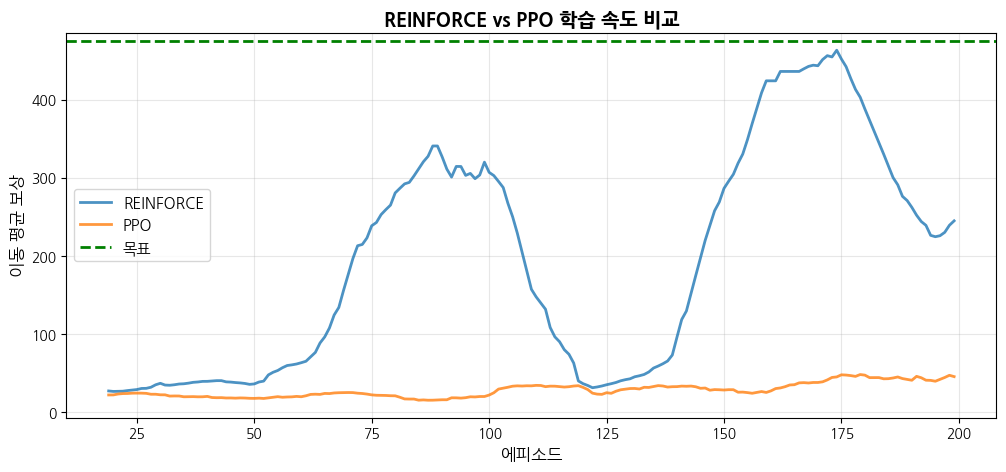


=== 비교 결과 ===
REINFORCE 평균 (마지막 50): 340.70
PPO 평균 (마지막 50): 500.00

PPO가 일반적으로 더 빠르고 안정적으로 학습합니다!


In [20]:
# 간단한 REINFORCE 구현 (비교용)
def train_reinforce(n_episodes=200):
    """
    간단한 REINFORCE 학습
    """
    env = gym.make('CartPole-v1')
    policy = create_actor_network(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.01)
    rewards_history = []

    for episode in range(n_episodes):
        states = []
        actions = []
        rewards = []
        log_probs = []

        state, _ = env.reset()
        done = False

        while not done:
            action, log_prob = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            log_probs.append(log_prob)
            state = next_state

        # Returns 계산
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + 0.99 * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # 업데이트
        policy_loss = sum(-lp * G for lp, G in zip(log_probs, returns))
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        rewards_history.append(sum(rewards))

    env.close()
    return rewards_history

print("비교 실험 중... (시간이 걸립니다)")
reinforce_rewards = train_reinforce(n_episodes=200)
print("REINFORCE 학습 완료")

# 비교 그래프
plt.figure(figsize=(12, 5))

window = 20

# REINFORCE
ma_reinforce = np.convolve(reinforce_rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(reinforce_rewards)), ma_reinforce,
         label='REINFORCE', linewidth=2, alpha=0.8)

# PPO (이전 결과 재사용)
if len(all_episode_rewards) >= window:
    # PPO는 에피소드 수가 다를 수 있으므로 처음 200개만
    ppo_first_200 = all_episode_rewards[:min(200, len(all_episode_rewards))]
    if len(ppo_first_200) >= window:
        ma_ppo = np.convolve(ppo_first_200, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(ppo_first_200)), ma_ppo,
                 label='PPO', linewidth=2, alpha=0.8)

plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='목표')
plt.xlabel('에피소드', fontsize=12)
plt.ylabel('이동 평균 보상', fontsize=12)
plt.title('REINFORCE vs PPO 학습 속도 비교', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== 비교 결과 ===")
print(f"REINFORCE 평균 (마지막 50): {np.mean(reinforce_rewards[-50:]):.2f}")
if len(all_episode_rewards) >= 50:
    print(f"PPO 평균 (마지막 50): {np.mean(all_episode_rewards[-50:]):.2f}")
print("\nPPO가 일반적으로 더 빠르고 안정적으로 학습합니다!")

**설명**: REINFORCE vs PPO

**차이점**:
1. **학습 속도**: PPO가 더 빠름
2. **안정성**: PPO가 덜 흔들림
3. **최종 성능**: PPO가 더 높은 점수

**이유**:
- PPO의 Clipping → 안정성
- 데이터 재사용 → 효율성
- Actor-Critic → 낮은 분산

---

## 마무리

### 배운 내용
1. PPO의 핵심 아이디어: **안전한 정책 업데이트**
2. Clipping 메커니즘: **큰 변화 방지**
3. Actor-Critic 구조: **정책 + 가치**
4. 데이터 효율성: **Multiple Epochs**

### PPO의 장점
- REINFORCE보다 빠르고 안정적
- 구현이 비교적 간단
- 다양한 환경에서 잘 작동
- 현업에서 가장 많이 사용

### PPO가 사용되는 곳
- ChatGPT (RLHF)
- 로봇 제어
- 게임 AI
- 자율주행

### 다음 단계
- 더 복잡한 환경에 도전
- 하이퍼파라미터 튜닝
- 다른 강화학습 알고리즘 탐색